In [1]:
import math
from pathlib import Path

import plotly.graph_objects as go
import polars as pl
from IPython.display import Image, display

In [2]:
def _choose_y_bounds(y_min: float, y_max: float) -> tuple[float, float]:
    # (y_max_threshold, upper_margin, rounding_step)
    upper_margin_step_by_ymax = [
        (0.1, 0.03, 0.02),
        (0.3, 0.05, 0.05),
        (0.6, 0.08, 0.1),
        (1.0, 0.12, 0.1),
        (1.5, 0.2, 0.1),
        (3.0, 0.3, 0.2),
        (7.0, 0.5, 0.5),
        (float("inf"), 0.8, 0.5),
    ]
    # (y_max_threshold, lower_margin)
    lower_margin_by_ymax = [
        (0.5, 0.03),
        (1.5, 0.06),
        (3.0, 0.12),
        (7.0, 0.2),
        (float("inf"), 0.3),
    ]

    if y_max <= 0:
        return -0.05, 1.1

    upper_margin, upper_step = next(
        (m, s) for t, m, s in upper_margin_step_by_ymax if y_max < t
    )
    y_upper = math.ceil((y_max + upper_margin) / upper_step) * upper_step
    y_upper = max(y_upper, 1.1)

    lower_margin = next(m for t, m in lower_margin_by_ymax if y_max < t)
    y_lower = min(0, y_min) - lower_margin
    return y_lower, y_upper


def _choose_y_dtick(y_lower: float, y_upper: float) -> float:
    candidates = [1.0, 2.0]
    span = y_upper - y_lower

    def score(dtick):
        n_ticks = span / dtick
        return abs(n_ticks - 3) if 2 <= n_ticks <= 4 else abs(n_ticks - 3) + 10

    return min(candidates, key=score)


def make_two_line_plot(
    x,
    y1,
    y2,
    name1="Line 1",
    name2="Line 2",
    legend_pos="upper right",  # "upper right", "upper left", or "lower left"
    width=600,
    height=360,
    x_range=(-0.3, 12.3),
    x_dtick=2,
    y_range=None,  # e.g. (-0.2, 1.4)
    save_filename="figure.png",
):
    legend_positions = {
        "upper right": dict(x=0.98, y=0.98, xanchor="right", yanchor="top"),
        "upper left": dict(x=0.02, y=0.98, xanchor="left", yanchor="top"),
        "lower left": dict(x=0.02, y=0.02, xanchor="left", yanchor="bottom"),
    }

    if legend_pos not in legend_positions:
        raise ValueError(
            "legend_pos must be 'upper right', 'upper left', or 'lower left'."
        )

    if y_range is None:
        y_min = min(min(y1), min(y2))
        y_max = max(max(y1), max(y2))
        y_lower, y_upper = _choose_y_bounds(y_min, y_max)
    else:
        y_lower, y_upper = y_range

    y_dtick = _choose_y_dtick(y_lower, y_upper)

    # traces
    fig = go.Figure()
    for y, name, color in [(y1, name1, "#636EFA"), (y2, name2, "gray")]:
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines+markers",
                name=name,
                line=dict(color=color, width=4),
                marker=dict(color=color, size=12, symbol="circle"),
            )
        )

    # layout and axes
    fig.update_layout(
        width=width,
        height=height,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font=dict(size=45, family="Times New Roman, Arial", color="black"),
        legend=dict(
            **legend_positions[legend_pos],
            bgcolor="rgba(255, 255, 255, 0.7)",
            bordercolor="gray",
            borderwidth=1,
            font=dict(color="black"),
        ),
        margin=dict(l=50, r=20, t=15, b=40, pad=0),
    )
    fig.update_xaxes(
        range=x_range,
        tick0=0,
        dtick=x_dtick,
        gridcolor="lightgray",
        zeroline=True,
        zerolinecolor="lightgray",
        zerolinewidth=1,
        showline=True,
        linecolor="black",
        linewidth=1,
        tickfont=dict(color="black"),
    )
    fig.update_yaxes(
        range=[y_lower, y_upper],
        tick0=0,
        dtick=y_dtick,
        gridcolor="lightgray",
        zeroline=True,
        zerolinecolor="lightgray",
        zerolinewidth=1,
        showline=True,
        linecolor="black",
        linewidth=1,
        tickfont=dict(color="black"),
    )

    # save and display
    save_path = Path(save_filename)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(str(save_path), format="png", width=width, height=height)
    display(Image(str(save_path)))
    # fig.write_image(str(save_path.with_suffix(".pdf")), format="pdf", width=width, height=height)
    # fig.show()

In [3]:
dataset_name = "wiki_1000"

model_name_alias = {
    "google-bert/bert-base-uncased": "BERT",
    "microsoft/MiniLM-L12-H384-uncased": "MiniLM",
    "thenlper/gte-base": "GTE<sub>base</sub>",
    "thenlper/gte-small": "GTE<sub>small</sub>",
    "h-tomo/unsup-simcse-bert-base-uncased-mean": "Unsup-SimCSE<sub>base</sub>",
    "intfloat/e5-base-v2": "E5<sub>base</sub>",
    "intfloat/e5-small-v2": "E5<sub>small</sub>",
    "sentence-transformers/all-MiniLM-L12-v2": "all-MiniLM-L12-v2",
}

backbone_and_text_encoders = {
    "google-bert/bert-base-uncased": [
        "thenlper/gte-base",
        "intfloat/e5-base-v2",
        "h-tomo/unsup-simcse-bert-base-uncased-mean",
    ],
    "microsoft/MiniLM-L12-H384-uncased": [
        "thenlper/gte-small",
        "intfloat/e5-small-v2",
        "sentence-transformers/all-MiniLM-L12-v2",
    ],
}

Backbone: BERT, Text Encoder: GTE<sub>base</sub>


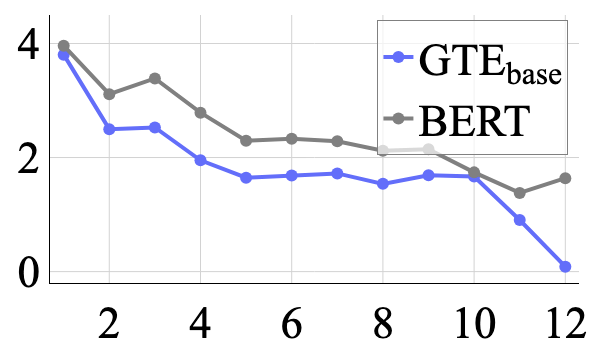

Backbone: BERT, Text Encoder: E5<sub>base</sub>


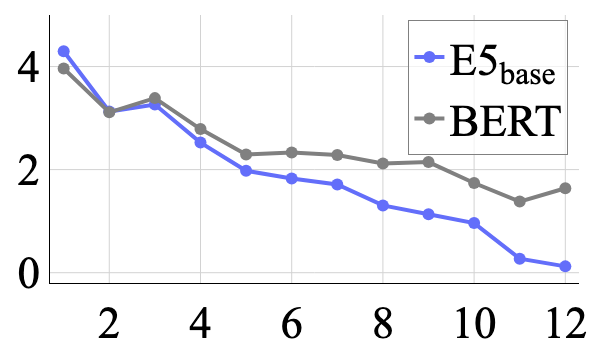

Backbone: BERT, Text Encoder: Unsup-SimCSE<sub>base</sub>


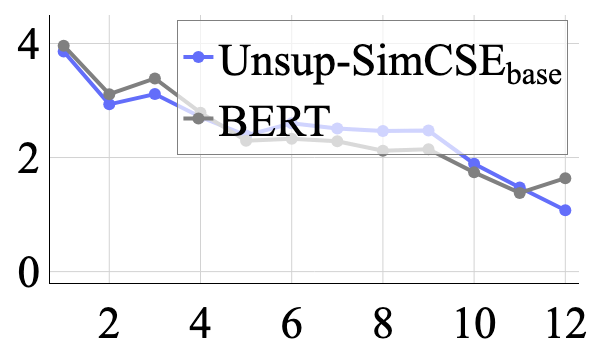

Backbone: MiniLM, Text Encoder: GTE<sub>small</sub>


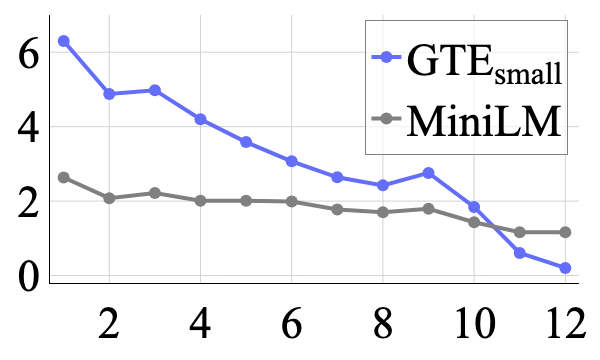

Backbone: MiniLM, Text Encoder: E5<sub>small</sub>


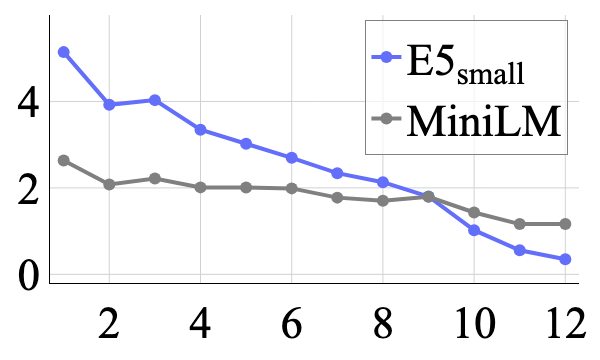

Backbone: MiniLM, Text Encoder: all-MiniLM-L12-v2


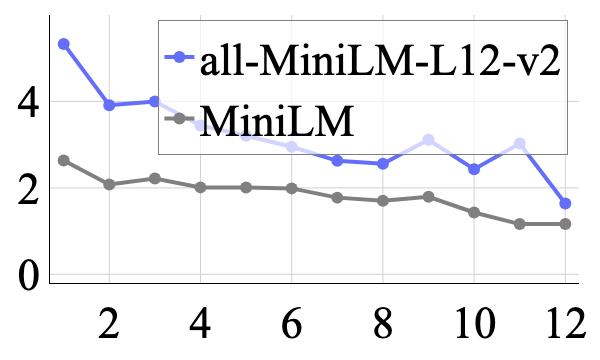

In [4]:
for backbone, text_encoders in backbone_and_text_encoders.items():
    for text_encoder in text_encoders:
        print(
            f"Backbone: {model_name_alias[backbone]}, Text Encoder: {model_name_alias[text_encoder]}"
        )

        df1 = (
            pl.read_csv(
                f"../results/token_concentration/{dataset_name}_{text_encoder.replace('/', '-')}.csv"
            )
            .filter(pl.col("layer") >= 0)
            .group_by("layer")
            .agg(pl.col("sx_over_mu_sq").mean())
            .sort("layer")
        )
        df2 = (
            pl.read_csv(
                f"../results/token_concentration/{dataset_name}_{backbone.replace('/', '-')}.csv"
            )
            .filter(pl.col("layer") >= 0)
            .group_by("layer")
            .agg(pl.col("sx_over_mu_sq").mean())
            .sort("layer")
        )

        x = (df1["layer"] + 1).to_list()

        make_two_line_plot(
            x=x,
            y1=df1["sx_over_mu_sq"].to_list(),
            y2=df2["sx_over_mu_sq"].to_list(),
            name1=model_name_alias[text_encoder],
            name2=model_name_alias[backbone],
            legend_pos="upper right",
            x_range=(0.7, 12.3),
            save_filename=f"./figs/token_concentration/{text_encoder.replace('/', '-')}_{backbone.replace('/', '-')}.png",
        )